All configuration and model checks passed.
Cores available: 64
Database generation complete
itmAC = 0.0, 0.0, 250.0
[0.    0.025 0.05  0.075 0.1  ]
Doing realization = 0
Doing realization = 1
Doing realization = 2
Doing realization = 3
Doing realization = 4
Doing realization = 5
Doing realization = 6
Doing realization = 7
Doing realization = 8
Doing realization = 9
Doing realization = 10
Doing realization = 11
Doing realization = 12
Doing realization = 13
Doing realization = 14
Doing realization = 15
Doing realization = 16
Doing realization = 17
Doing realization = 18
Doing realization = 19
Doing realization = 20
Doing realization = 21
Doing realization = 22
Doing realization = 23
Doing realization = 24
Doing realization = 25
Doing realization = 26
Doing realization = 27
Doing realization = 28
Doing realization = 29
Doing realization = 30
Doing realization = 31
Doing realization = 32
Doing realization = 33
Doing realization = 34
Doing realization = 35
Doing realization = 36
Doing reali

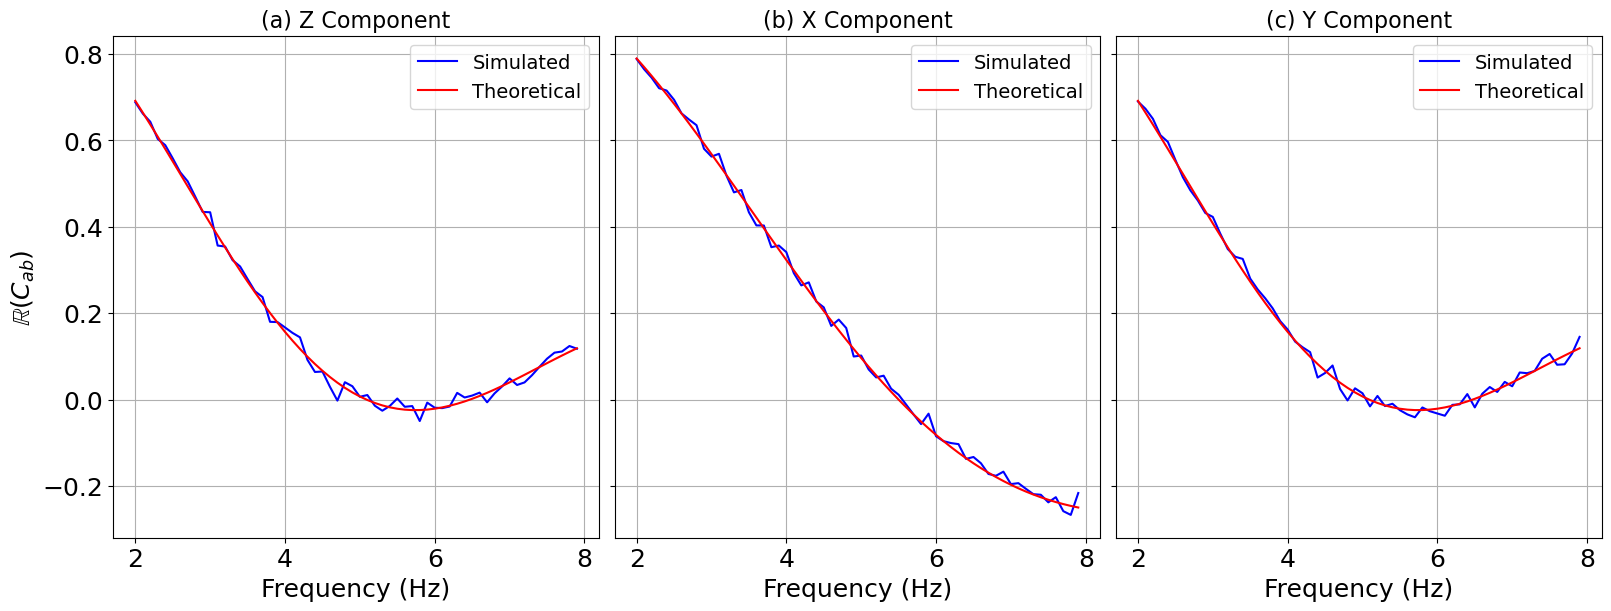

In [ ]:
# script for computing NN for any layered model for different cavity geometries
import numpy as np
import os
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from scipy.io import savemat
from scipy.io import loadmat
from scipy.integrate import quad, tplquad, dblquad
import scipy.constants as const
from scipy.special import spherical_jn
from scipy.special import jv

from pysurf96 import surf96
from modules import configLoader
from modules import validateInputs
from modules import createDB
from modules import NNGeometryN
from modules import NNGeometryNN
from modules import gfLoader
from modules import simDisp
from modules import NNCompute
from modules import NNPP
from modules import plotUtils

def main():

    # load the config file
    configFile="/home/koley/CavityResults/SphCCTutorialConfig/configParseCCBodyHomo.ini"
    config = configLoader.load_config(configFile)
    # load all cavities
    allCavities = configLoader.loadCavities('/home/koley/CavityResults/SphCCTutorialConfig/SingleSphCavity.ini')
    validateInputs.validateInputs(config)
    
    splitAll = createDB.createFinalInputs(config)

    print(f"Prepared {splitAll.shape[0]} total runs")
    print(f"Cores available: {config.cpuCoresQseis}")

    results = createDB.runMultiQseis(splitAll, config.inputPath, config.qseisExe, nWorkers = config.cpuCoresQseis)
    
    print("Database generation complete")
    
    # flag for pure Rayleigh wavefield in homogeneous half-space
    ifRay = config.ifRay

    # flag for plane P and S waves in homogeneous half space
    ifBody = config.ifBody

    # flag for wavefield simulation
    ifFullField = config.ifFullField

    saveHV = config.saveHV

    thickness = config.thickness # units in meters
    vs = config.vS # units in m/s
    vp = config.vP # units in m/s
    rho = config.rho # units in kg/m^3
    rhoAir = config.rhoAir # density of air
    fMin = config.fMin; fMax = config.fMax; df = config.df;# units in Hz
    lambdaFrac = config.lambdaFrac # fraction
    lambdaRes = config.lambdaRes; #must be greater than 4
    
    # given a cuboidal domain should be greater than sqrt of 
    xMaxGF = config.xMaxGF # maximum horizontal offset upto which displacements will be used
    zMaxGF = config.zMaxGF # maximum depth upto which displacements will be used
    maxRec = config.maxRec # same value of number of receivers that qseis can handle in one go check qsglobal.h
    xCenter = config.xCenter; yCenter = config.yCenter
    xMin = xCenter-config.xExtent; xMax = xCenter+config.xExtent # minimum and maximum of the simulation domain in X-direction (EW)
    yMin = yCenter-config.yExtent; yMax = yCenter+config.yExtent # maximum and minimum of the simulation domain in Y-direction (NS)
    zMin = 0.0; zMax = config.zExtent # maximum and minimum of the simulation domain in Z-direction (depth)

    # check if the GFs are generated up to correct hoizontal offsets
    xDiag = (xMax-xMin)*np.sqrt(2); yDiag = (yMax-yMin)*np.sqrt(2);
    if(xMaxGF<xDiag or xMaxGF<yDiag):
        raise ValueError("xMaxGF must be >= sqrt(2)x(xMax-xMin) and sqrt(2)x(yMax-yMin)")

    if(zMaxGF<zMax):
        raise ValueError("zMaxGF must be greater >= zMax")


    itmAC = config.itmAC; itmAB = config.itmAB; etmCA = config.etmCA; etmBA = config.etmBA

    print('itmAC = ' + str(itmAC[0]) + ', ' + str(itmAC[1]) + ', ' + str(itmAC[2]))
    # make itmAC[2] negative, because in the configfile it is positive
    itmACUse = itmAC.copy(); itmACUse[2] = -np.abs(itmACUse[2])
    itmABUse = itmAB.copy(); itmABUse[2] = -np.abs(itmABUse[2])
    etmCAUse = etmCA.copy(); etmCAUse[2] = -np.abs(etmCAUse[2])
    etmBAUse = etmBA.copy(); etmBAUse[2] = -np.abs(etmBAUse[2])
    # just add one test-mass location, rather than all
    itmAll = np.vstack((itmACUse,))
    nTM = len(itmAll[:,0])
    G = const.G
    
    # some other inputs for simDisp
    maxRec = config.maxRec; # same value of number of receivers that qseis can handle in one go check qsglobal.h
    tMax = config.tMax; nSamp = config.nSamp
    
    # specify the folder where you want to write all input files, should have rw access
    # fInpPath is the path where the Green's function database exists
    fInpPath = config.inputPath #like "/data/gravwav/koley/QseisInpN/"
    #fInpPath = "/data/gravwav/koley/SALVUSOut/"

    # outDispPath should have rw access and is used for saving temp displacementy files
    outDispPath = config.outDispPath # like "/data/gravwav/koley/OutDisp/"

    # GF components to be used
    components = ['fh-2.tz', 'fh-2.tr', 'fh-2.tt', 'fz-2.tz', 'fz-2.tr']

    # splitAll is necessary so load it
    nRea = config.nRea # number of realizations
    nRea = 2000
    # this file is created at the time of database generation
    splitFileName = fInpPath + 'splitAll.mat'
    splitMat = loadmat(splitFileName)
    splitAll = splitMat['splitAll']

    # source distribution parameters
    R1 = config.R1; R2 = config.R2
    nSrc = config.nSrc
    srcDistri = config.srcDistri
    scaleVH = config.scaleVH
    # flag if NN is computed directly without writing the displacemnet field
    onFlyNN = config.onFlyNN 

    # number of CPUs to be used for displacement and NN simulation
    nCPUDisp = config.cpuCoresDisp
    computeStrategy = config.computeStrategy

    # frequency axis to be used by simDisp
    freqOut, idxFreq, df_native = simDisp.getFreqGrid(tMax, nSamp, fMin, fMax, df)
    nFreq = len(freqOut)

    splitAllNew, tVecN = gfLoader.assembleQseisRuns(splitAll, fInpPath, components, outPath=None, fIndices=idxFreq, minVel=100.0)
    #splitAllNew = np.load(os.path.join(fInpPath,'splitAllNew.npy'))
     
    # in case only Rayleigh waves in homogeneous half space is used, Rayleigh wave phase velocity is needed
    if(ifRay):
        periods = 1/freqOut
        vR = surf96(thickness,vp,vs,rho,periods,wave="rayleigh",mode=1,velocity="phase",flat_earth=True)
    else:
        vR = None
    # two depth points for scaling, displacement saved per realization
    zTar = 0
    # generate the two points between which CC will be computed
    gridX = np.array((0.0, 250.0,))
    gridY = np.array((0.0, 0.0,))
    recDistAB = np.sqrt((gridX[0]-gridX[1])**2 + (gridY[0]-gridY[1])**2)
    # prepare containers
    ccAAZ = np.zeros((nFreq,))
    ccBBZ = np.zeros((nFreq,))
    ccABZ = np.zeros((nFreq,),dtype =np.complex128)

    ccAAX = np.zeros((nFreq,))
    ccBBX = np.zeros((nFreq,))
    ccABX = np.zeros((nFreq,),dtype=np.complex128)
    
    ccAAY = np.zeros((nFreq,))
    ccBBY = np.zeros((nFreq,))
    ccABY = np.zeros((nFreq,),dtype=np.complex128)
    
    for reaNo in range(0,nRea):
        print('Doing realization = ' +str(reaNo))
        # get the source distribution per realization
        xSrc, ySrc, azSrc, srcMeta =  simDisp.genAmbSrc(nSrc , mode = srcDistri, R1 = R1, R2 = R2, xMin=xMin, xMax=xMax, yMin=yMin,
                                           yMax=yMax, randomPhase=True, freqDependent=True, nFreq=nFreq, decoupledHV=config.decoupledHV,
                                           scaleVH = scaleVH)
        
        # in case the body wave in homogeneous half-space flag is turned on
        if(ifBody):
            metaBody = simDisp.genBodySrc(nSrc, nFreq, eP = 1/3, eS = 2/3)       
        else:
            metaBody=None
        
        if(ifBody):
            dispTotal = simDisp.computeFullBodyDisp_parallel(-zTar, gridX, gridY, nSrc, freqOut, vp[0], vs[0], metaBody,
                                 n_workers=nCPUDisp)
        elif(ifRay):
            if(zTar>0):
                zTar = -zTar
            dispTotal = simDisp.computeRayleighDisp(zTar, gridX, gridY, nSrc, freqOut, azSrc,
                                                    srcMeta["phiV"], srcMeta["ampV"], vR, vp[0], vs[0])
        else:
            # fullfield case
            dispTotal, _, _, shmPaths = simDisp.computeFullDispF(zTar, gridX, gridY, itmAC, xSrc, ySrc, azSrc, srcMeta,idxFreq, freqOut, outDispPath,
                         splitAllNew, xMaxGF, fInpPath, nCPU=nCPUDisp, nChunk=20000, computeStrategy=computeStrategy,
                         saveHV=False, reduceNN=onFlyNN, nnMode=None, nnMeta=None)
            
        ccAAZ += (np.abs(dispTotal[:,0,2]))**2
        ccBBZ += (np.abs(dispTotal[:,1,2]))**2
        ccABZ += dispTotal[:,0,2]*np.conj(dispTotal[:,1,2])

        ccAAX += (np.abs(dispTotal[:,0,0]))**2
        ccBBX += (np.abs(dispTotal[:,1,0]))**2
        ccABX += dispTotal[:,0,0]*np.conj(dispTotal[:,1,0])
        
        ccAAY += (np.abs(dispTotal[:,0,1]))**2
        ccBBY += (np.abs(dispTotal[:,1,1]))**2
        ccABY += dispTotal[:,0,1]*np.conj(dispTotal[:,1,1])

        if(ifFullField):
            del dispTotal
            simDisp.cleanup_sharedmem(shmPaths)
    
    # now get the real part and plot
    ccRealZ = np.real(ccABZ/np.sqrt(ccAAZ*ccBBZ))
    ccRealX = np.real(ccABX/np.sqrt(ccAAX*ccBBX))
    ccRealY = np.real(ccABY/np.sqrt(ccAAY*ccBBY))

    plotUtils.set_plot_style("medium")
    figCC, axCC = plotUtils.plotCCDeepSurfMulti(freqOut, ccRealZ, ccRealX, ccRealY, 'Simulated', 'b', fig=None, axs=None, quantity=r"$\mathbb{R}(C_{ab})$")
    #print(len(freqOut))
    if(ifBody):
        pM = 2
        periods = 1/freqOut
        vR = surf96(thickness,vp,vs,rho,periods,wave="rayleigh",mode=1,velocity="phase",flat_earth=True)
   
        j0R = jv(0,2*np.pi*recDistAB*freqOut/vR)
        j2R = jv(2,2*np.pi*recDistAB*freqOut/vR)
        # spherical
        j0P = spherical_jn(0,2*np.pi*recDistAB*freqOut/vp[0])
        j2P = spherical_jn(2,2*np.pi*recDistAB*freqOut/vp[0])
        j0S = spherical_jn(0,2*np.pi*recDistAB*freqOut/vs[0])
        j2S = spherical_jn(2,2*np.pi*recDistAB*freqOut/vs[0])
        ccZ = ((j0P+j2P) + pM*(j0S-1/2*j2S))/(1+pM)
        ccX = ((j0P-2*j2P) + pM*(j0S+j2S))/(1+pM)
        ccY = ((j0P+j2P) + pM*(j0S-1/2*j2S))/(1+pM)
        fTheo = freqOut

    if(ifRay):
        j0R = jv(0,2*np.pi*recDistAB*freqOut/vR)
        j2R = jv(2,2*np.pi*recDistAB*freqOut/vR)
        vR = 1
        ccZ = (vR*j0R)/(vR)
        ccX = (vR*(j0R-j2R))/(vR) 
        ccY = (vR*(j0R+j2R))/(vR)
        fTheo = freqOut

    if(ifFullField):
        j0R, j0L, fJ = simDisp.getBessel(thickness,vp,vs,rho,fMin,fMax,recDistAB,love=False)
        # get the second order Bessels
        j2R, j2L, fJ = simDisp.getBesselN(thickness,vp,vs,rho,fMin,fMax,recDistAB,2,love=False)

        j4R, j4L, fJ = simDisp.getBesselN(thickness,vp,vs,rho,fMin,fMax,recDistAB,4,love=False)
        
        vR = 1.0; hR = 1.0
        ccZ = (vR*j0R + hR*(j0R)/1)/(hR+vR)
        ccX = (vR*(j0R-j2R)+ hR*(j0R))/(vR+hR) 
        ccY = (vR*(j0R+j2R)+ hR*(j0R))/(vR+hR)
        
        fTheo = fJ

    #print(len(freqOut))
    axCC[0].plot(fTheo, ccZ, 'r', label="Theoretical")
    axCC[0].legend(loc="upper right")
    axCC[0].xaxis.label.set_size(18)
    axCC[0].yaxis.label.set_size(18)
    axCC[0].tick_params(axis="both", labelsize=18)
    
    if(ifBody):
        axCC[1].plot(fTheo,ccX,'r',label= "Theoretical")
    else:    
        axCC[1].plot(fTheo,j0R,'r',label= "Theoretical")
        axCC[1].plot(fTheo,j0R-j2R,'m',label= "Theoretical")
    
    axCC[1].legend(loc="upper right")
    axCC[1].xaxis.label.set_size(18)
    axCC[1].yaxis.label.set_size(18)
    axCC[1].tick_params(axis="both", labelsize=18)

    if(ifBody):
        axCC[2].plot(fTheo,ccY,'r',label="Theoretical")
    else:
        axCC[2].plot(fTheo,j0R,'r',label="Theoretical")
        axCC[2].plot(fTheo,j0R+j2R,'m',label= "Theoretical")
    
    axCC[2].legend(loc="upper right")
    axCC[2].xaxis.label.set_size(18)
    axCC[2].yaxis.label.set_size(18)
    axCC[2].tick_params(axis="both", labelsize=18)

if __name__ == "__main__":
    main()